In [3]:
#change the path to your working directory

base_dir = '/scratch/mjehangir/Glioma_project/glioma_aneuploidy/'
setwd(base_dir)

In [4]:
library(ComplexHeatmap)
library(circlize)
#library(gridExtra)
library(RColorBrewer)
library(ggpubr)
library(tidyverse)
library(ggplot2)
library(dplyr)
library(corrplot)
library(circlize)


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [5]:
#load the data files

summary_file = read.csv(file = "/scratch/mjehangir/Glioma_project/glioma_aneuploidy//Glioma_v3_CNV_stats.txt", header = TRUE, sep = "\t")


In [6]:
head(summary_file)

,SampleID,seqnames,arm,arm_call,arm_num_seg,arm_cr_wmean,arm_cr_wsd
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,6423A,chr21,21p,1,1,1.3206974,0.00000000
2,6436B,chr17,17p,0,1,0.9829569,0.00000000
3,6266D,chr17,17p,0,1,1.0289693,0.00000000
4,6265D,chr18,18p,0,1,0.9759641,0.00000000
5,6298B,chr17,17p,0,1,1.0329712,0.00000000
6,6500D,chr16,16p,0,2,0.9394281,0.02082144


In [20]:
#extract selected columns to plot heatmaps
summary_file2 = summary_file %>% select("SampleID", "prop_aneuploidy", "aneuploidy_score", "aneuploidy_amp_score", "aneuploidy_del_score")

In [21]:
head(summary_file2)

,SampleID,prop_aneuploidy,aneuploidy_score,aneuploidy_amp_score,aneuploidy_del_score
,<chr>,<dbl>,<int>,<int>,<int>
1,2436A,0.1274,0,0,0
2,3188,0.8723,8,2,6
3,3988,0.3572,2,1,1
4,6265D,0.6488,0,0,0
5,6266D,0.1347,1,1,0
6,6269C,0.5780,1,1,0


In [22]:

#load clinical data file (this dataset was extracted from excel)
clin_dat = read.table(file = "/scratch/mjehangir/manuscript_figures/manuscript_data/clinical_data.txt", header = TRUE, sep = "\t")

In [23]:
head(clin_dat, n=20)
# Remove rows with any NA values
clin_dat <- na.omit(clin_dat)
head(clin_dat, n=2)


,ID,Age,Grade,CDKN2A.B,TP53,ATRX,onco_Alterations,ONT_Alterations
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2436A,NA,3,NA,NA,NA,5,40
2,3188,NA,3,NA,NA,NA,16,107
3,3988,0,2,2,0,0,17,105
4,6265D,33,3,1,0,0,42,87
5,6266D,40,2,1,0,0,28,105
6,6269C,23,3,2,0,0,14,214
7,6277A,40,3,1,0,0,70,138
8,6285B,64,3,1,2,2,7,66
9,6298B,34,3,2,0,2,6,40


,ID,Age,Grade,CDKN2A.B,TP53,ATRX,onco_Alterations,ONT_Alterations
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
3,3988,0,2,2,0,0,17,105
4,6265D,33,3,1,0,0,42,87


In [24]:
head(summary_file2)

,SampleID,prop_aneuploidy,aneuploidy_score,aneuploidy_amp_score,aneuploidy_del_score
,<chr>,<dbl>,<int>,<int>,<int>
1,2436A,0.1274,0,0,0
2,3188,0.8723,8,2,6
3,3988,0.3572,2,1,1
4,6265D,0.6488,0,0,0
5,6266D,0.1347,1,1,0
6,6269C,0.5780,1,1,0


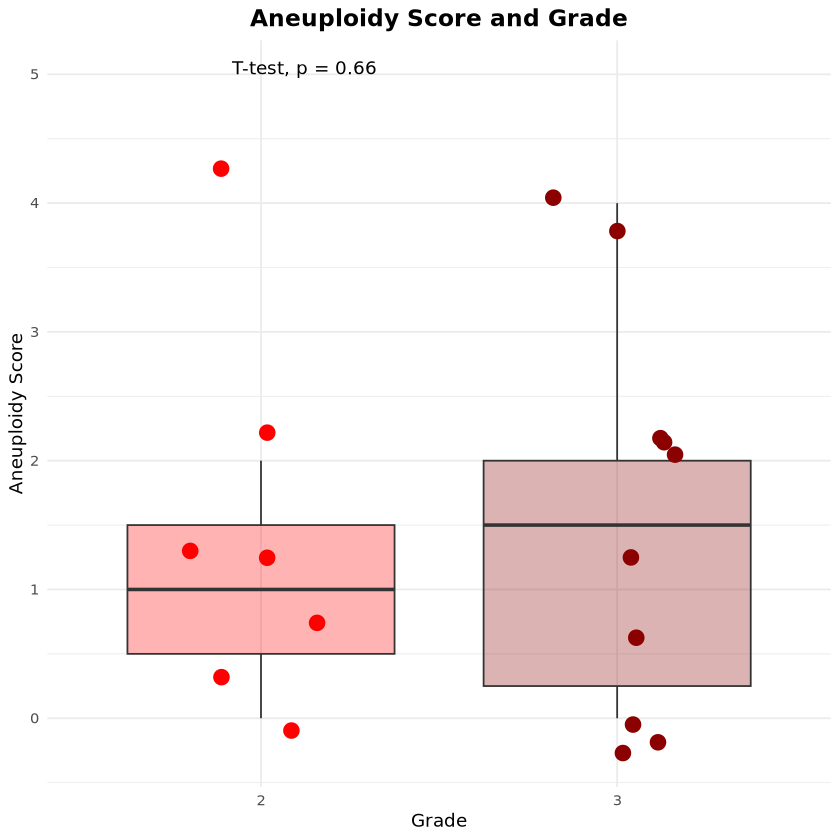

In [25]:

# Merge the summary and clinical datasets by SampleID and ID
merged_data <- summary_file2 %>%
  inner_join(clin_dat, by = c("SampleID" = "ID"))

# Ensure Grade is a factor for categorical plotting
merged_data$Grade <- as.factor(merged_data$Grade)

# Plot the boxplot with jittered points
p <- ggplot(merged_data, aes(x = Grade, y = aneuploidy_score)) +
  geom_boxplot(aes(fill = Grade), outlier.shape = NA, alpha = 0.3) + # Boxplot
  geom_jitter(width = 0.2, size = 4, aes(color = Grade)) + # Jittered points
  scale_fill_manual(values = c("1" = "grey", "2" = "red", "3" = "darkred")) + # Custom fill colors
  scale_color_manual(values = c("2" = "red", "3" = "darkred")) + # Custom point colors
  theme_minimal() +
  labs(
    title = "Aneuploidy Score and Grade",
    x = "Grade",
    y = "Aneuploidy Score"
  ) +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold")
  )

# Perform a t test and add p-values
p <- p + stat_compare_means(method = "t.test", label.y = max(merged_data$aneuploidy_score) + 1)

print(p)


In [16]:

chr_arm_seg_data_data = read.csv(file = "./test_CNV_stats.txt", header = TRUE, sep = "\t")

chr_arm_seg_data_data <- chr_arm_seg_data_data %>%
  group_by(SampleID, arm) %>%
  summarise(arm_call = first(arm_call), .groups = "drop")


In [17]:
head(chr_arm_seg_data_data)

SampleID,arm,arm_call
<chr>,<chr>,<int>
2436A,10q,NA
2436A,11p,NA
2436A,12p,NA
2436A,12q,NA
2436A,14q,NA
2436A,15p,NA


In [18]:
data_wide <- chr_arm_seg_data_data %>%
  pivot_wider(names_from = arm, values_from = arm_call)


In [19]:
# Remove chromosome arms (columns) that contain only NA values
data_wide <- data_wide %>%
  select(where(~ any(!is.na(.)))) 

# Remove samples (rows) where all values are NA or 0 (except SampleID)
data_wide <- data_wide %>%
  filter(if_any(-SampleID, ~ !is.na(.) & . != 0))


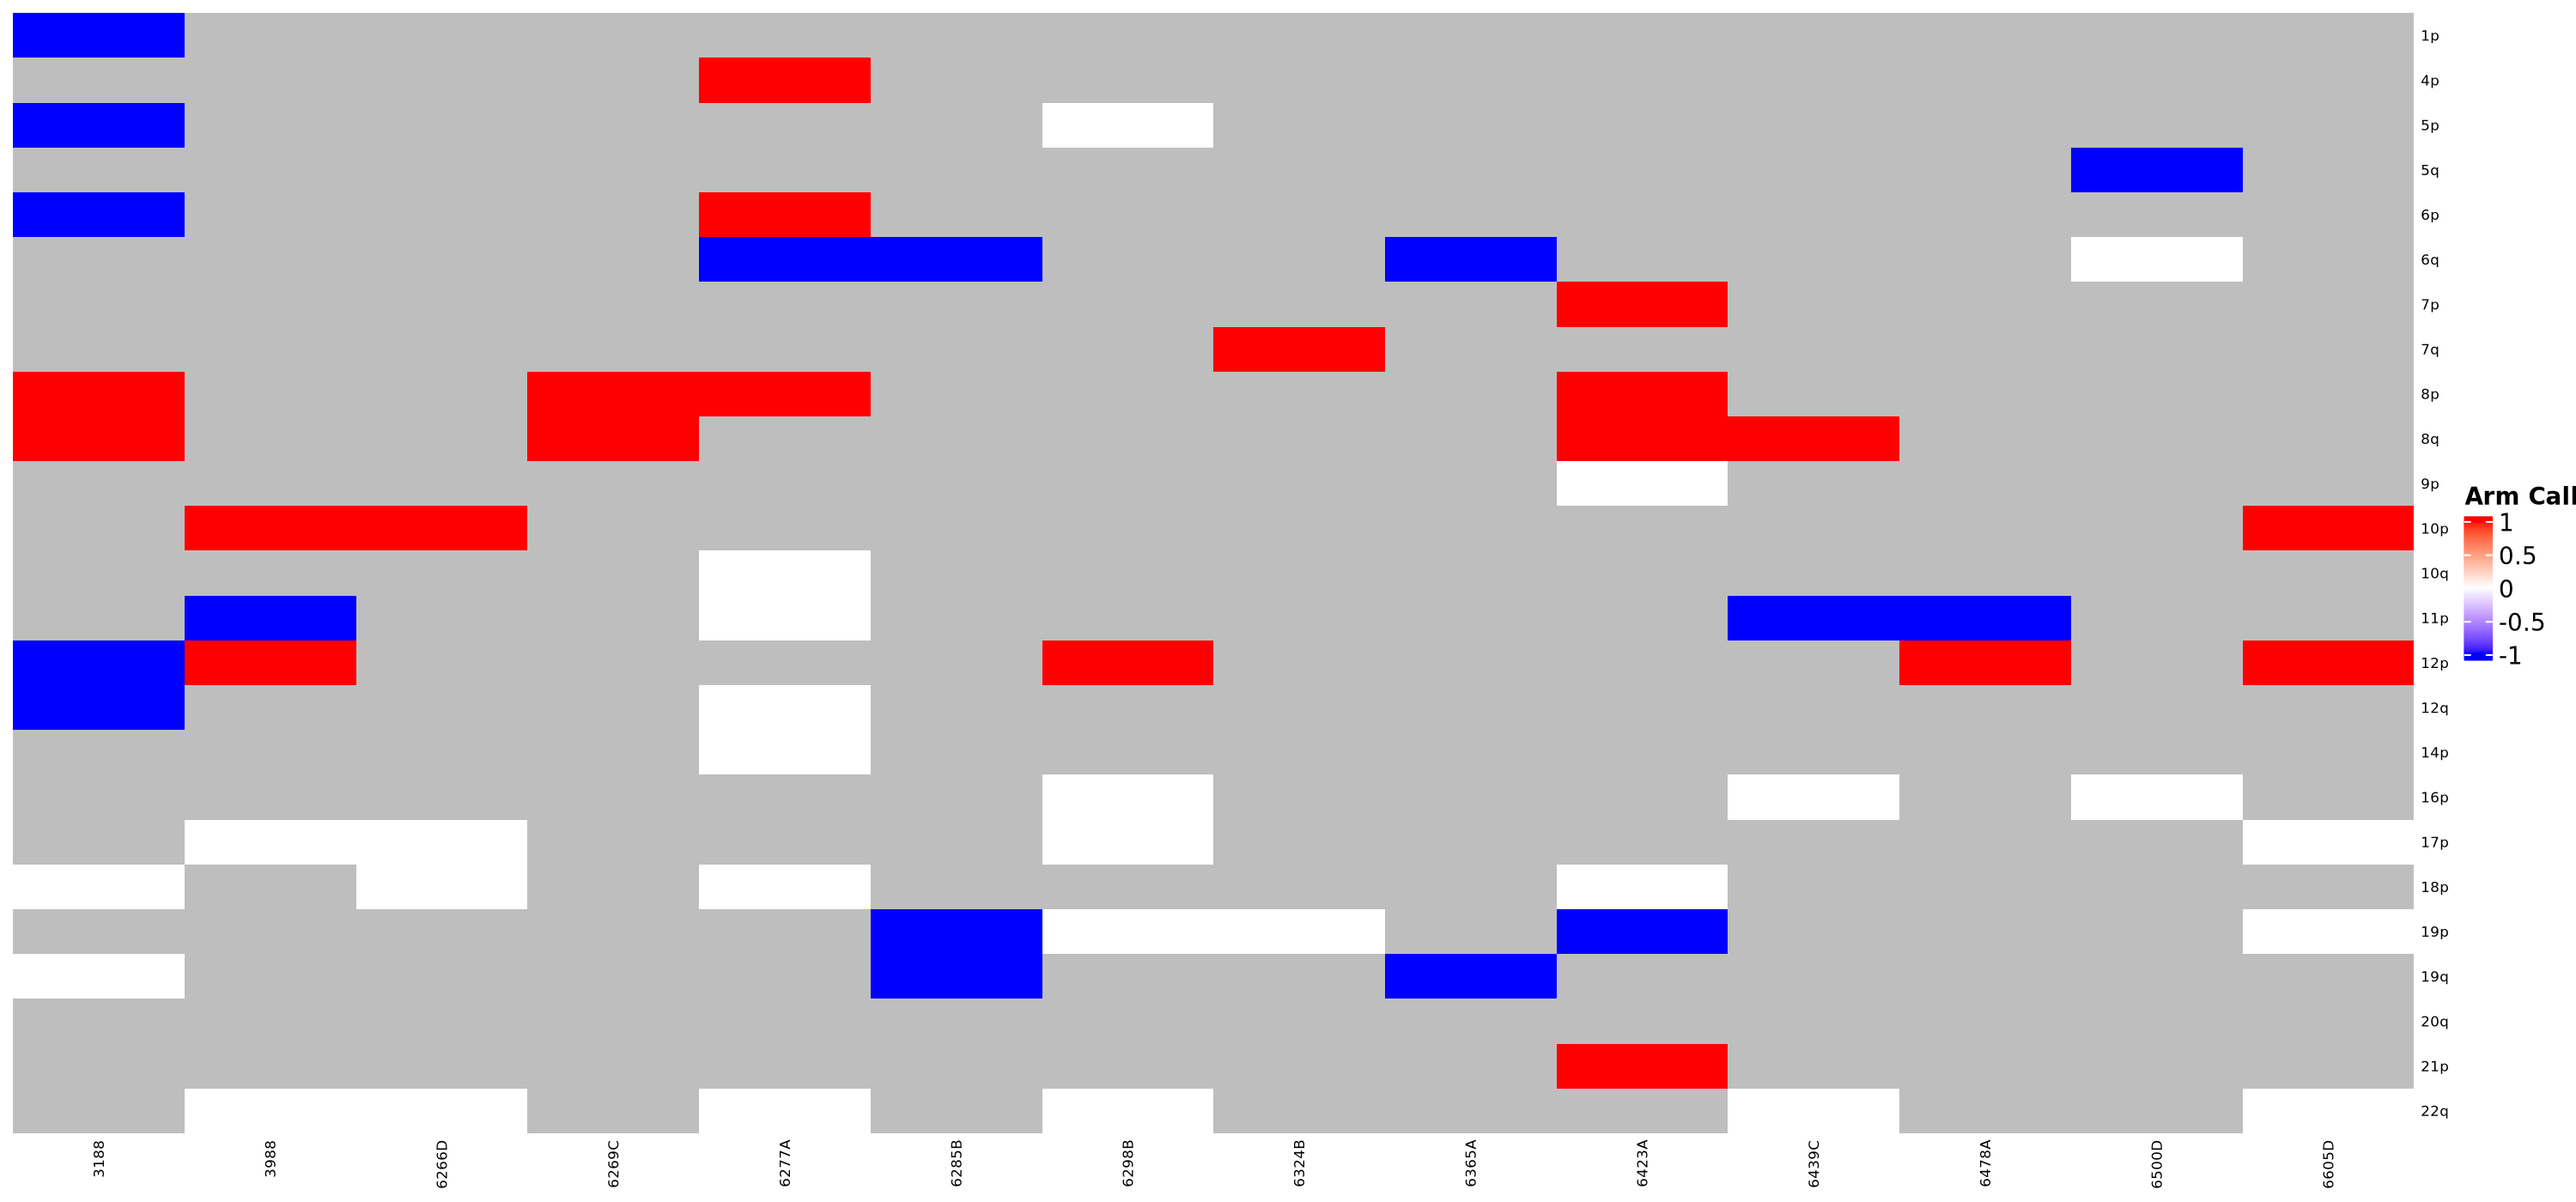

In [20]:
# Sort chromosome arms naturally (e.g., chr1p, chr1q, chr2p, chr2q, ..., chrXq)
sorted_arms <- colnames(data_wide)[-1]  # Exclude SampleID column
sorted_arms <- sorted_arms[order(
  as.numeric(str_extract(sorted_arms, "\\d+")),  # Extract numeric parts for chromosomes
  str_extract(sorted_arms, "[a-z]+")  # Extract arm suffix (p/q)
)]

# Apply sorted arms to the data
data_wide <- data_wide %>%
  select(SampleID, all_of(sorted_arms))

# Convert to matrix
heatmap_matrix <- as.matrix(data_wide[, -1])
rownames(heatmap_matrix) <- data_wide$SampleID  # Set row names as Sample IDs

# Define color mapping: Blue (-1 = Loss), White (0 = Neutral), Red (1 = Gain)
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))

heatmap_matrix_transposed <- t(heatmap_matrix)
# Open a PDF device with standard letter size dimensions
#pdf(file = "heatmap_glass.pdf", width = 12, height = 8)
# Generate the heatmap with swapped axes
Heatmap(heatmap_matrix_transposed, 
        name = "Arm Call", 
        col = col_fun,
        show_row_names = TRUE, 
        show_column_names = TRUE,
        cluster_rows = FALSE,   # Keep chromosomes (rows) in order
        cluster_columns = FALSE, # Keep samples (columns) in order
        row_names_gp = gpar(fontsize = 6),  # Adjust row name font size
        column_names_gp = gpar(fontsize = 6) # Adjust column name font size
)
# Close the device to save the file
#dev.off()
options(repr.plot.width = 15, repr.plot.height = 7, repr.plot.res = 200)


In [15]:
head(heatmap_matrix_transposed)

2436A,3188,3988,6265D,6266D,6269C,6277A,6285B,6298B,6314E,6324B,6365A,6414C,6423A,6436B,6439C,6478A,6483C,6500D,6605D


    Chromosome_Arm Gain_Count Loss_Count
1p              1p          0          1
4p              4p          1          0
5p              5p          0          1
5q              5q          0          1
6p              6p          1          1
6q              6q          0          3
7p              7p          1          0
7q              7q          1          0
8p              8p          4          0
8q              8q          4          0
9p              9p          0          0
10p            10p          3          0
10q            10q          0          0
11p            11p          0          3
12p            12p          4          1
12q            12q          0          1
14p            14p          0          0
16p            16p          0          0
17p            17p          0          0
18p            18p          0          0
19p            19p          0          2
19q            19q          0          2
20q            20q          0          0
21p            2

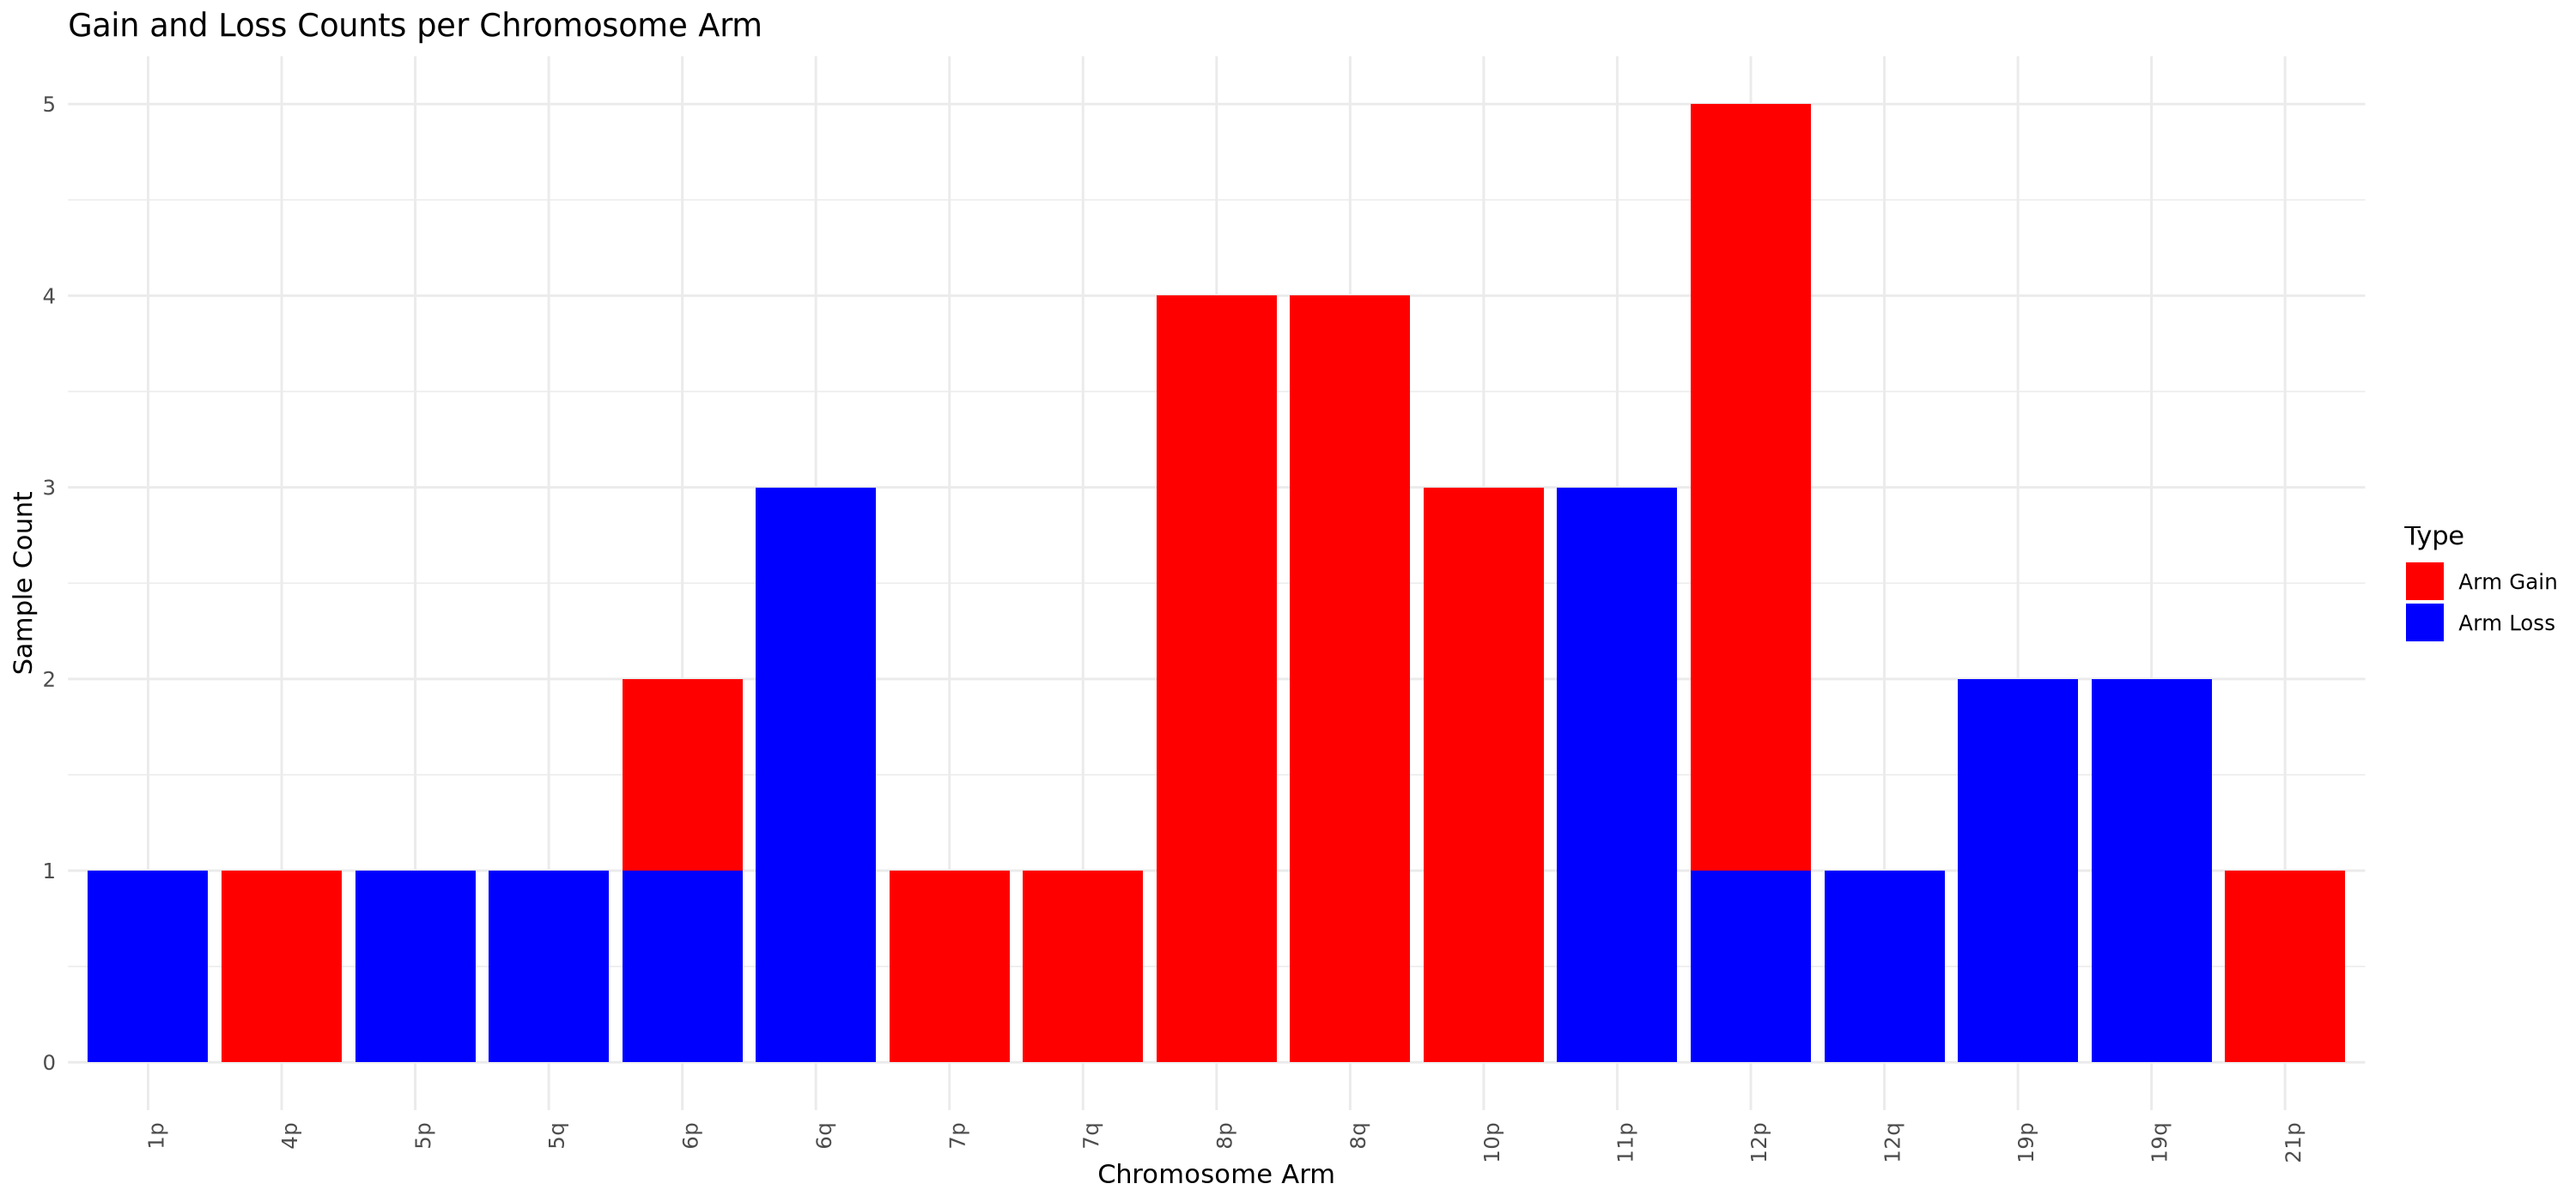

In [21]:
# Assume first column contains chromosome arms
# Convert the matrix to a data frame
heatmap_matrix_transposed <- as.data.frame(heatmap_matrix_transposed)

# Assume first column contains chromosome arms and assign it as rownames
heatmap_matrix_transposed$Chromosome_Arm <- rownames(heatmap_matrix_transposed)


# Count occurrences of 1 and -1 per chromosome arm (excluding the first column)
count_heatmap_matrix_transposed <- heatmap_matrix_transposed %>%
  mutate(
    Gain_Count = rowSums(. == 1, na.rm = TRUE),   # Count of 1 (gain)
    Loss_Count = rowSums(. == -1, na.rm = TRUE)   # Count of -1 (loss)
  ) %>%
  select(Chromosome_Arm, Gain_Count, Loss_Count)
# Print the results
print(count_heatmap_matrix_transposed)

 
# Reshape the count data to long format for plotting
count_df_long <- count_heatmap_matrix_transposed %>%
  gather(key = "Type", value = "Count", Gain_Count, Loss_Count)



# Filter out chromosome arms with zero total count
count_df_long <- count_df_long %>%
  group_by(Chromosome_Arm) %>%
  mutate(Total = sum(Count)) %>%
  filter(Total != 0) %>%  # Keep only arms with gain or loss
  ungroup() 

# Sort by total count in descending order
#count_df_long <- count_df_long %>%
 # arrange(desc(Total))

# Ensure Chromosome_Arm is a factor with levels in sorted order
count_df_long$Chromosome_Arm <- factor(count_df_long$Chromosome_Arm, 
                                       levels = unique(count_df_long$Chromosome_Arm))

# Plot the sorted stacked bar plot
ggplot(count_df_long, aes(x = Chromosome_Arm, y = Count, fill = Type)) +
  geom_bar(stat = "identity") +  # Stacked bars
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(title = "Gain and Loss Counts per Chromosome Arm", 
       x = "Chromosome Arm", 
       y = "Sample Count") +
  scale_fill_manual(values = c("red", "blue"), labels = c("Arm Gain", "Arm Loss"))

In [14]:
tl_data = read.csv(file = "/scratch/mjehangir/manuscript_figures/manuscript_data/gliomas_telomers.csv", header = TRUE, sep = ",")
head(tl_data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm
,<chr>,<chr>,<dbl>,<int>,<chr>
1,2436A,chr1p,5221.000,1,p
2,2436A,chr1q,5051.167,1,q
3,3188,chr1p,1642.500,1,p
4,3188,chr1q,3086.500,1,q
5,3988,chr1p,2347.500,1,p
6,3988,chr1q,5083.000,1,q


In [22]:
library(dplyr)
library(stringr)

# Process chr_arm_seg_data_data: split arm into chr number and arm letter
chr_arm_seg_data_data <- chr_arm_seg_data_data %>%
  mutate(
    chr_num = str_extract(arm, "\\d+"),  # extract chromosome number
    arm_letter = str_extract(arm, "[pq]")  # extract arm letter p or q
  )

# Process tl_data: convert 'chr' to match format in chr_arm_seg_data_data
tl_data <- tl_data %>%
  mutate(
    chr_num = str_extract(chr, "\\d+"),  # extract chromosome number
    arm_letter = arm  # already has p or q in arm column
  )

# Now create a consistent arm variable in tl_data
tl_data <- tl_data %>%
  mutate(arm_full = paste0(chr_num, arm_letter))

# Similarly for chr_arm_seg_data_data
chr_arm_seg_data_data <- chr_arm_seg_data_data %>%
  mutate(arm_full = paste0(chr_num, arm_letter))

# Merge by SampleID/Sample_prefix and arm_full
merged_data <- inner_join(
  chr_arm_seg_data_data,
  tl_data,
  by = c("SampleID" = "Sample_prefix", "arm_full" = "arm_full")
)

# Check merged data columns
head(merged_data)


SampleID,arm.x,arm_call,chr_num.x,arm_letter.x,arm_full,chr,final_average_TL_p75,chr_order,arm.y,chr_num.y,arm_letter.y
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>
2436A,10q,NA,10,q,10q,chr10q,2732.75,10,q,10,q
2436A,11p,NA,11,p,11p,chr11p,6766.00,11,p,11,p
2436A,12p,NA,12,p,12p,chr12p,5319.40,12,p,12,p
2436A,12q,NA,12,q,12q,chr12q,6085.00,12,q,12,q
2436A,14q,NA,14,q,14q,chr14q,3490.60,14,q,14,q
2436A,15q,NA,15,q,15q,chr15q,4111.50,15,q,15,q


In [24]:
colnames(merged_data)


[1] "SampleID"             "arm.x"                "arm_call"            
 [4] "chr_num.x"            "arm_letter.x"         "arm_full"            
 [7] "chr"                  "final_average_TL_p75" "chr_order"           
[10] "arm.y"                "chr_num.y"            "arm_letter.y"

In [25]:
perform_test <- function(data, group_comp = c(1,0,-1), group1, group2) {
  # Filter by unique arm_full value
  current_arm <- unique(data$arm_full)
  
  data_sub <- data %>%
    filter(arm_full == current_arm) %>%
    filter(arm_call %in% group_comp) %>%
    mutate(group = case_when(
      arm_call %in% group1 ~ "Group1",
      arm_call %in% group2 ~ "Group2"
    ))
  
  if(length(unique(data_sub$group)) < 2) {
    # Not enough groups for test
    return(data.frame(
      arm = current_arm,
      p_value = NA,
      group1 = paste(group1, collapse = ","),
      group2 = paste(group2, collapse = ",")
    ))
  }
  
  wilcox_test <- wilcox.test(final_average_TL_p75 ~ group, data = data_sub)
  return(data.frame(
    arm = current_arm,
    p_value = wilcox_test$p.value,
    group1 = paste(group1, collapse = ","),
    group2 = paste(group2, collapse = ",")
  ))
}

arms <- unique(merged_data$arm_full)  # or use arm.x

results_list <- list()

for (arm_i in arms) {
  dat_arm <- merged_data %>% filter(arm_full == arm_i)
  
  res1 <- perform_test(dat_arm, group_comp = c(1,0,-1), group1 = c(1), group2 = c(0,-1))
  res2 <- perform_test(dat_arm, group_comp = c(1,0,-1), group1 = c(-1), group2 = c(0,1))
  res3 <- perform_test(dat_arm, group_comp = c(1,0,-1), group1 = c(1,-1), group2 = c(0))
  
  results_list[[paste0(arm_i, "_comp1")]] <- res1
  results_list[[paste0(arm_i, "_comp2")]] <- res2
  results_list[[paste0(arm_i, "_comp3")]] <- res3
}

results_df <- do.call(rbind, results_list)
print(results_df)


          arm   p_value group1 group2
10q_comp1 10q        NA      1   0,-1
10q_comp2 10q        NA     -1    0,1
10q_comp3 10q        NA   1,-1      0
11p_comp1 11p        NA      1   0,-1
11p_comp2 11p 1.0000000     -1    0,1
11p_comp3 11p 1.0000000   1,-1      0
12p_comp1 12p 0.4000000      1   0,-1
12p_comp2 12p 0.4000000     -1    0,1
12p_comp3 12p        NA   1,-1      0
12q_comp1 12q        NA      1   0,-1
12q_comp2 12q 1.0000000     -1    0,1
12q_comp3 12q 1.0000000   1,-1      0
14q_comp1 14q        NA      1   0,-1
14q_comp2 14q        NA     -1    0,1
14q_comp3 14q        NA   1,-1      0
15q_comp1 15q        NA      1   0,-1
15q_comp2 15q        NA     -1    0,1
15q_comp3 15q        NA   1,-1      0
16p_comp1 16p        NA      1   0,-1
16p_comp2 16p        NA     -1    0,1
16p_comp3 16p        NA   1,-1      0
16q_comp1 16q        NA      1   0,-1
16q_comp2 16q        NA     -1    0,1
16q_comp3 16q        NA   1,-1      0
17q_comp1 17q        NA      1   0,-1
17q_comp2 17

In [26]:
merged_filtered <- merged_data %>% filter(arm_call %in% c(-1, 0, 1))

# +1 vs (0,-1)
merged_filtered <- merged_filtered %>%
  mutate(group = ifelse(arm_call == 1, "Group1", "Group2"))
test_overall_comp1 <- wilcox.test(final_average_TL_p75 ~ group, data = merged_filtered)
print(test_overall_comp1$p.value)

# -1 vs (0,+1)
merged_filtered <- merged_filtered %>%
  mutate(group = ifelse(arm_call == -1, "Group1", "Group2"))
test_overall_comp2 <- wilcox.test(final_average_TL_p75 ~ group, data = merged_filtered)
print(test_overall_comp2$p.value)

# (+1,-1) vs 0
merged_filtered <- merged_filtered %>%
  mutate(group = ifelse(arm_call %in% c(1,-1), "Group1", "Group2"))
test_overall_comp3 <- wilcox.test(final_average_TL_p75 ~ group, data = merged_filtered)
print(test_overall_comp3$p.value)


[1] 0.502853
[1] 0.004745262
[1] 0.001908162


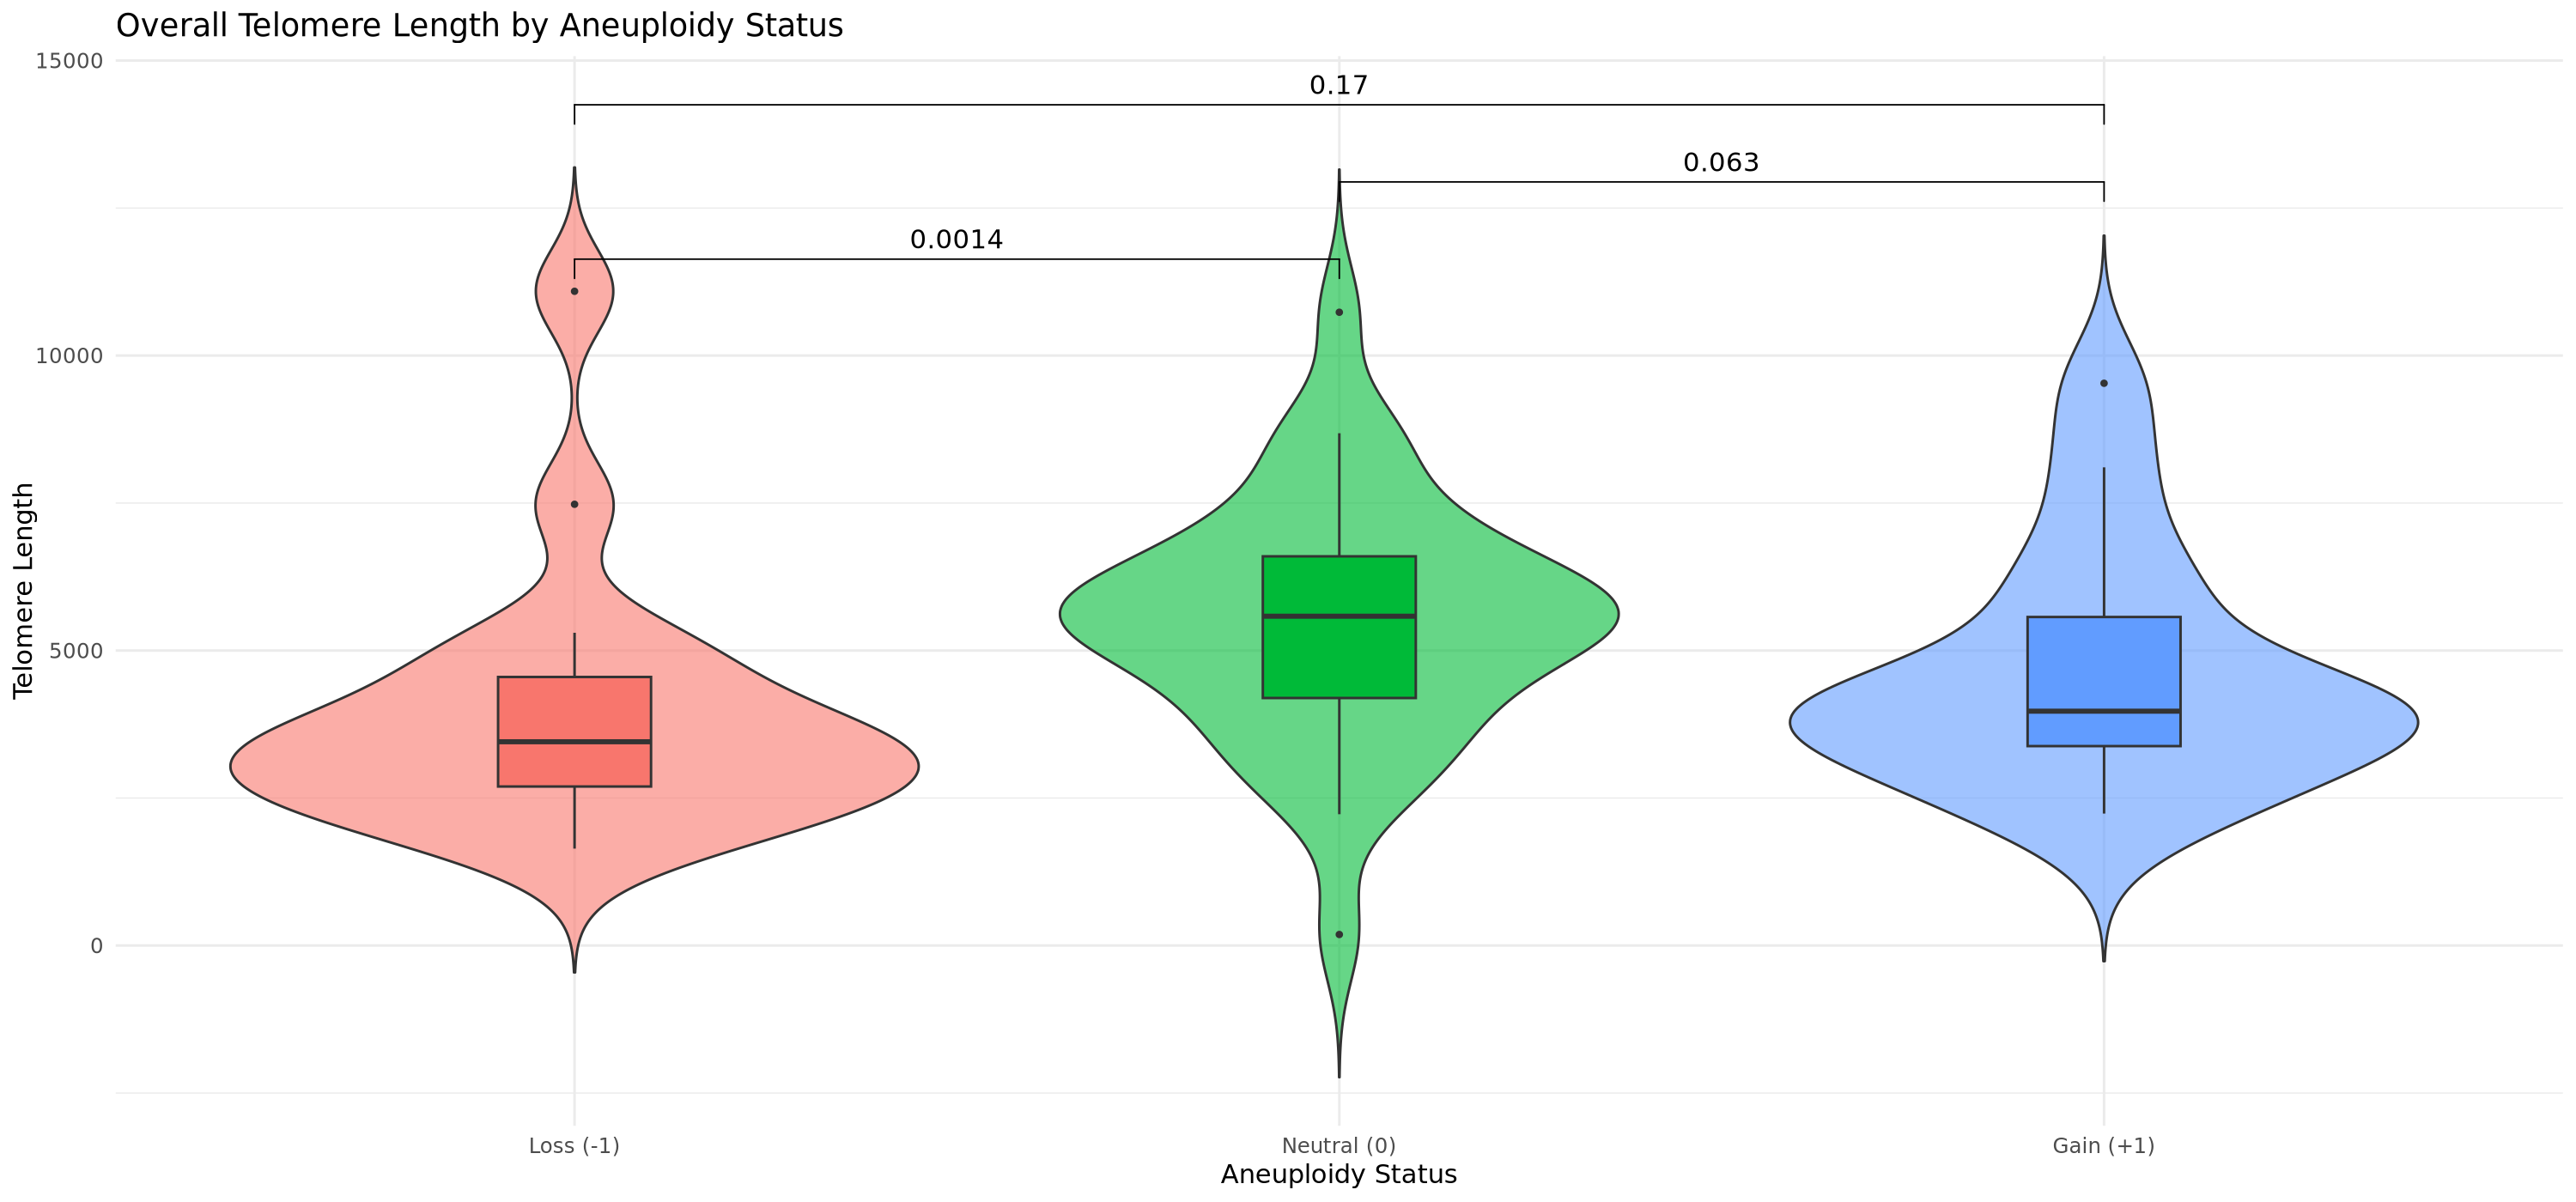

Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”


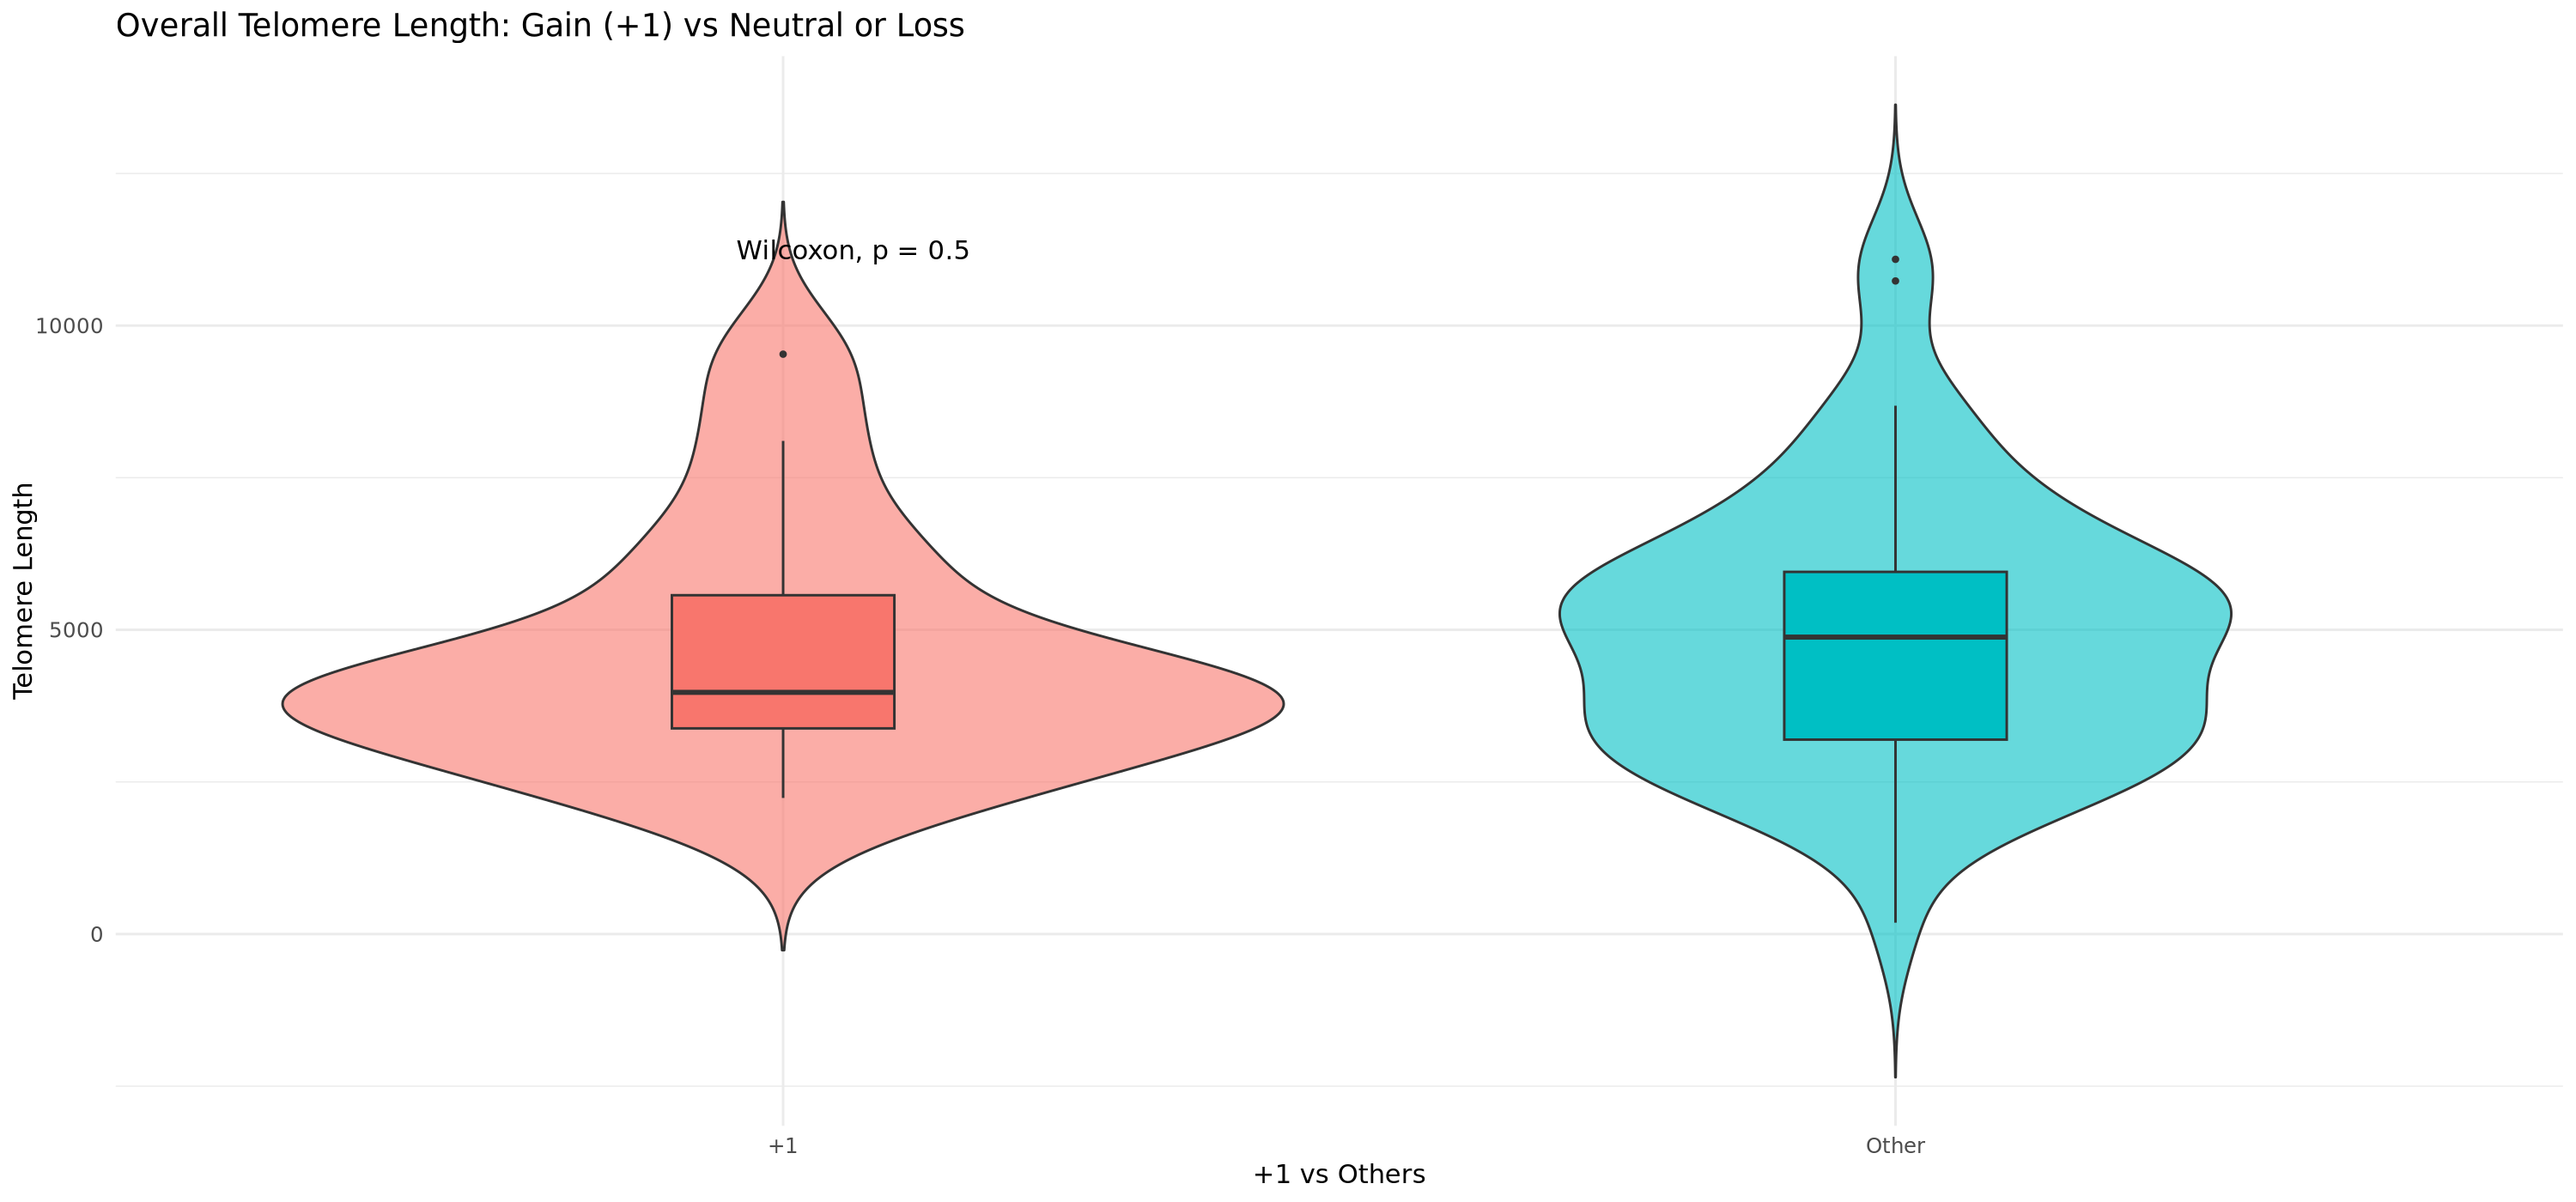

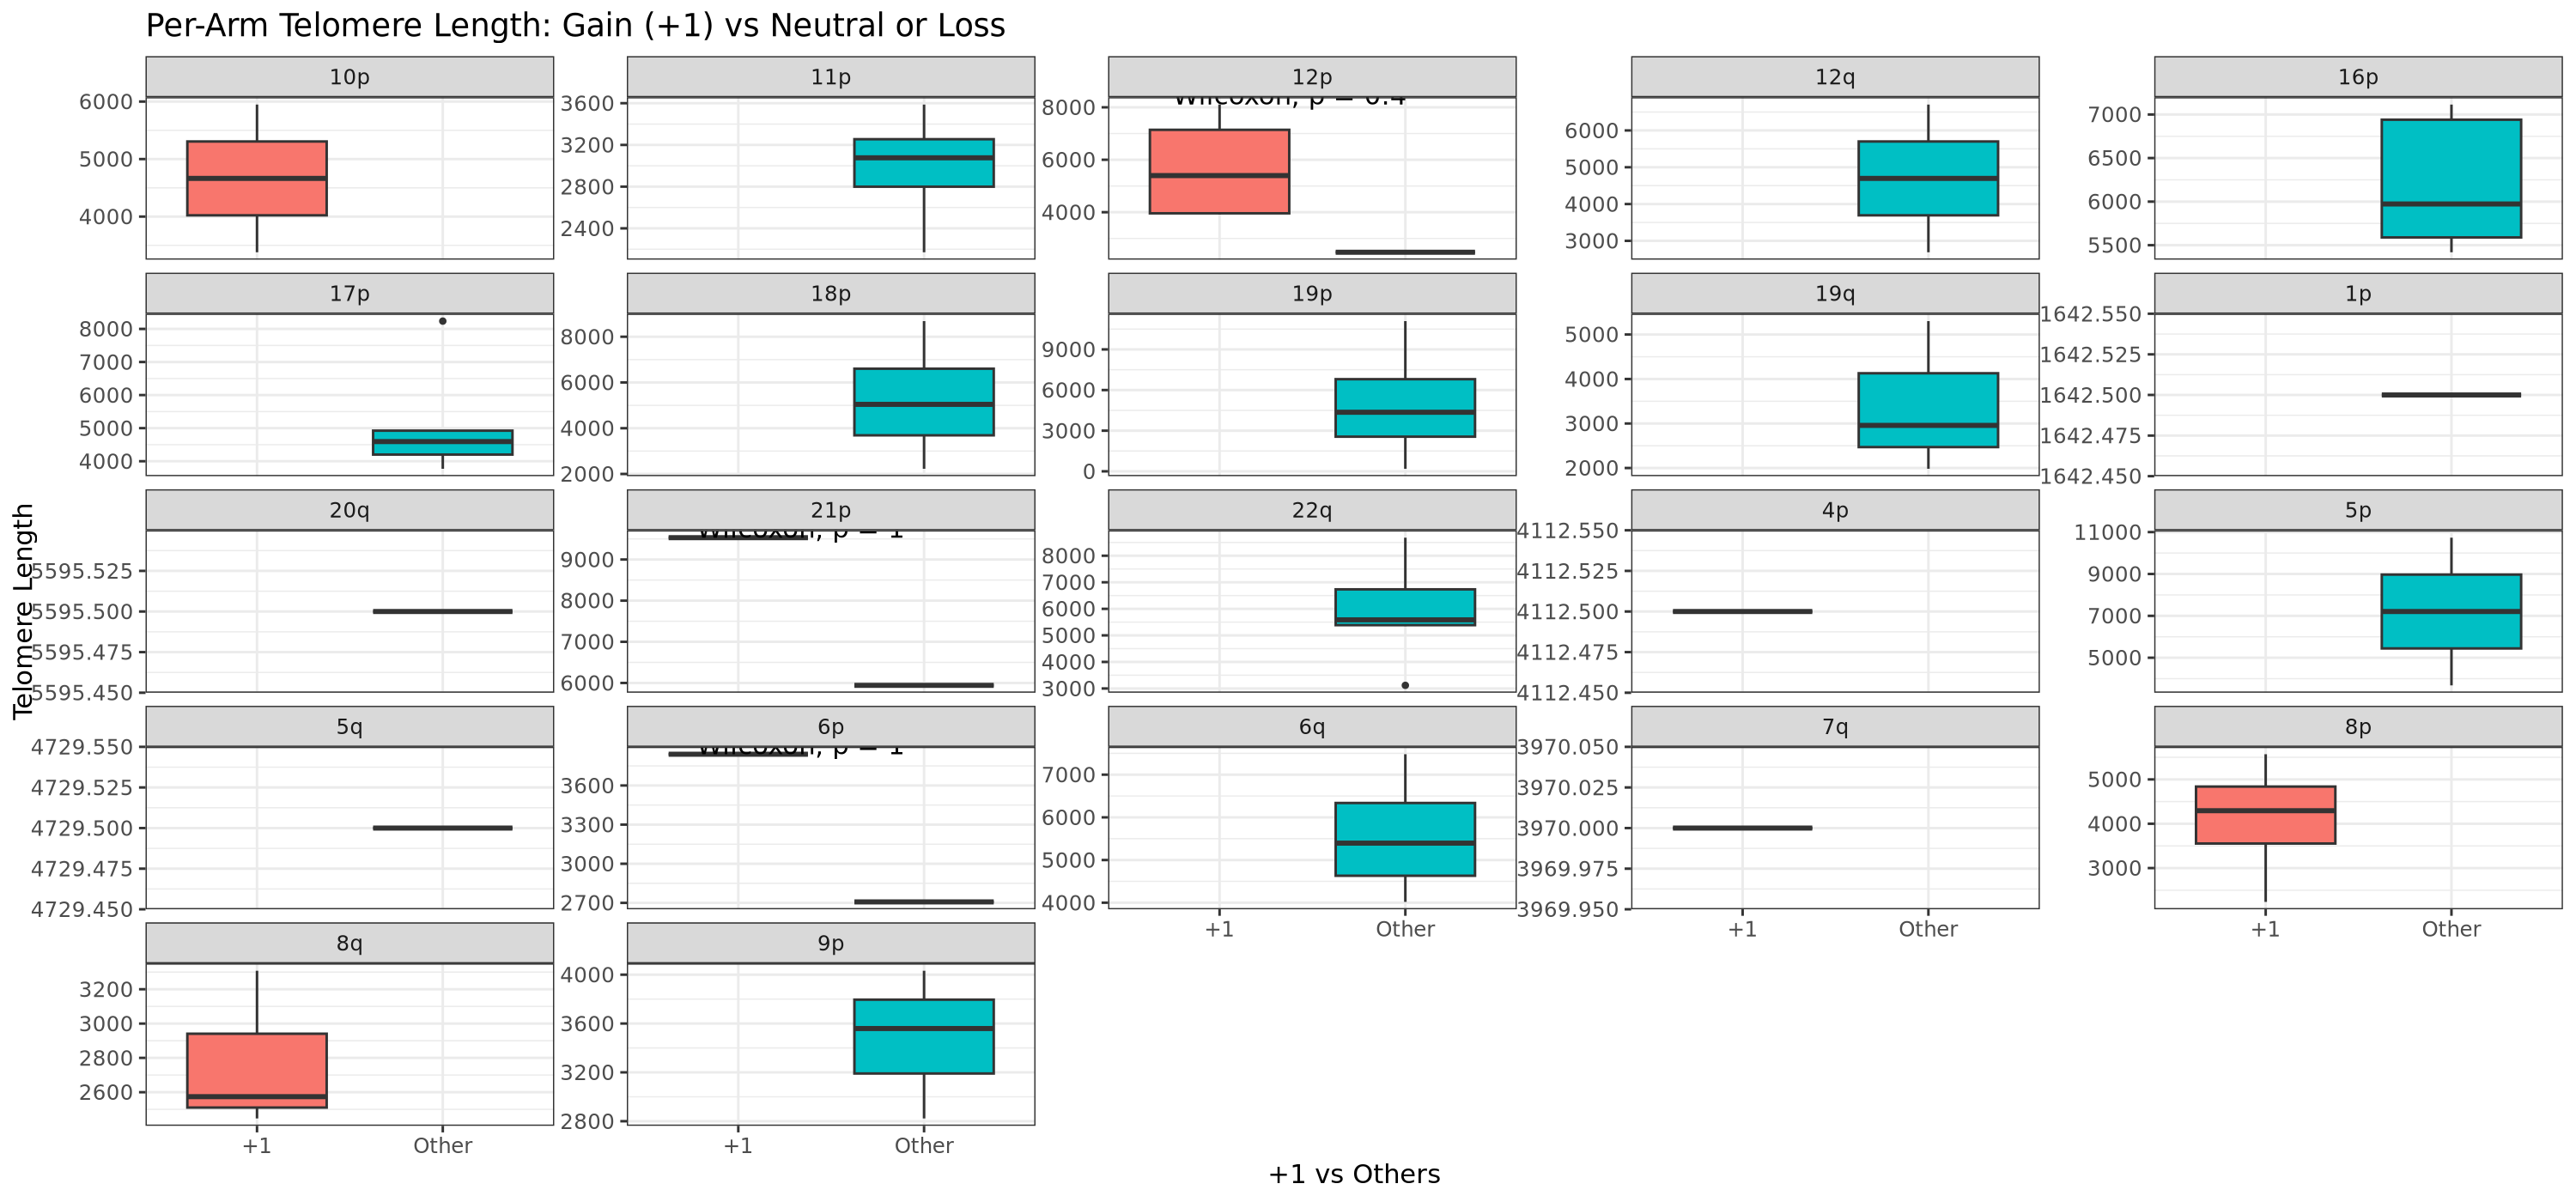

Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”


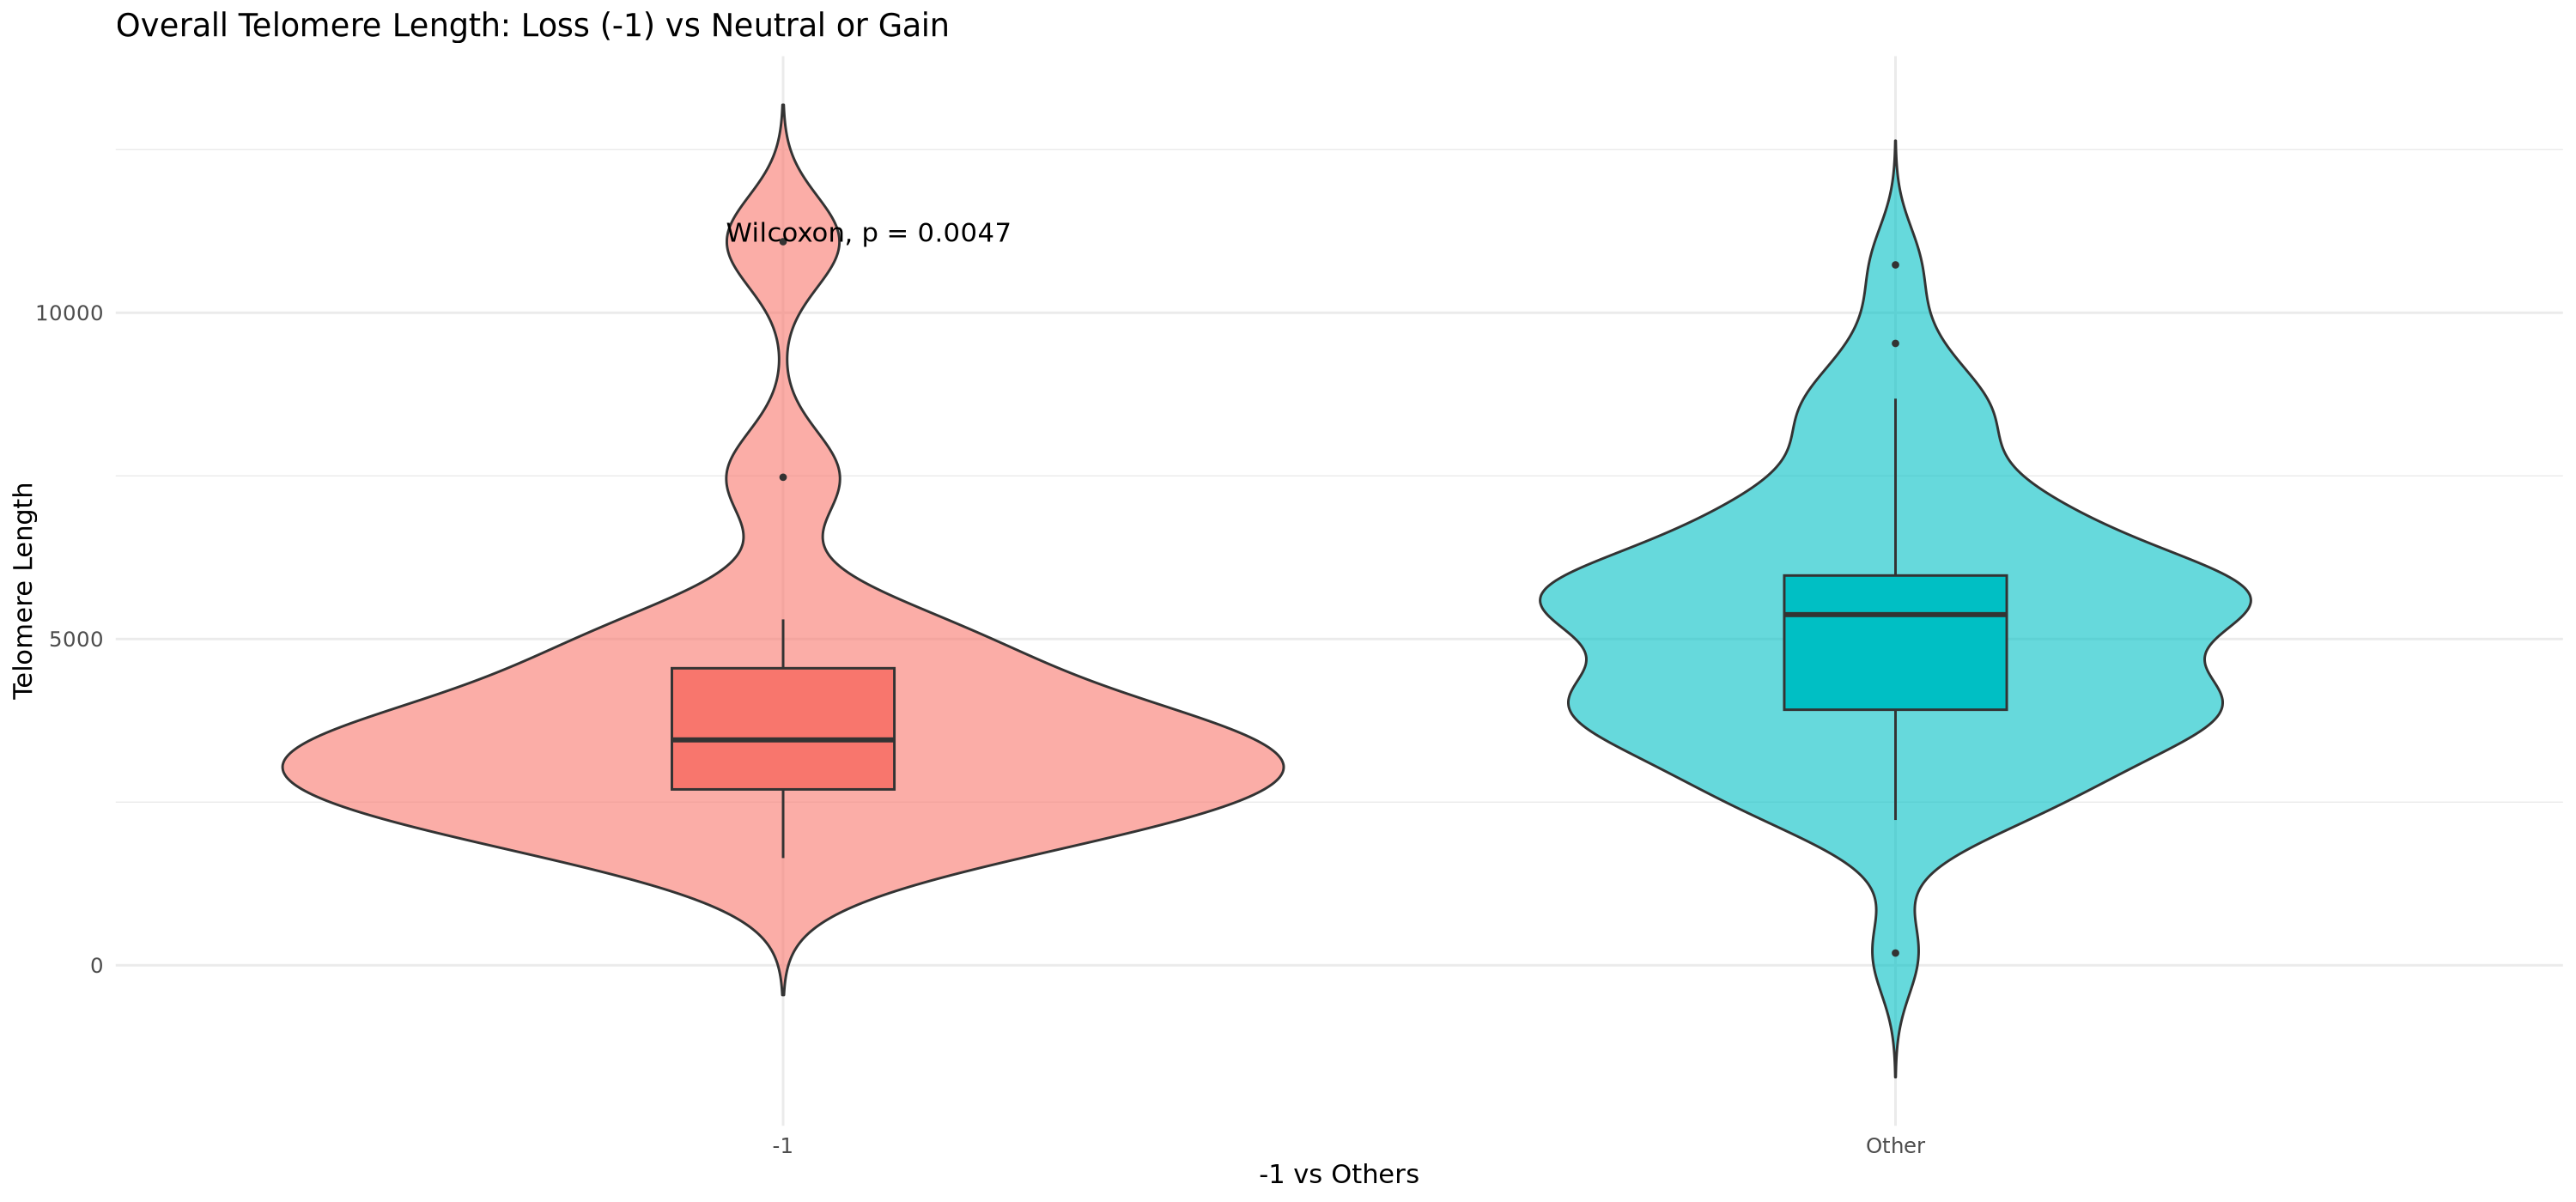

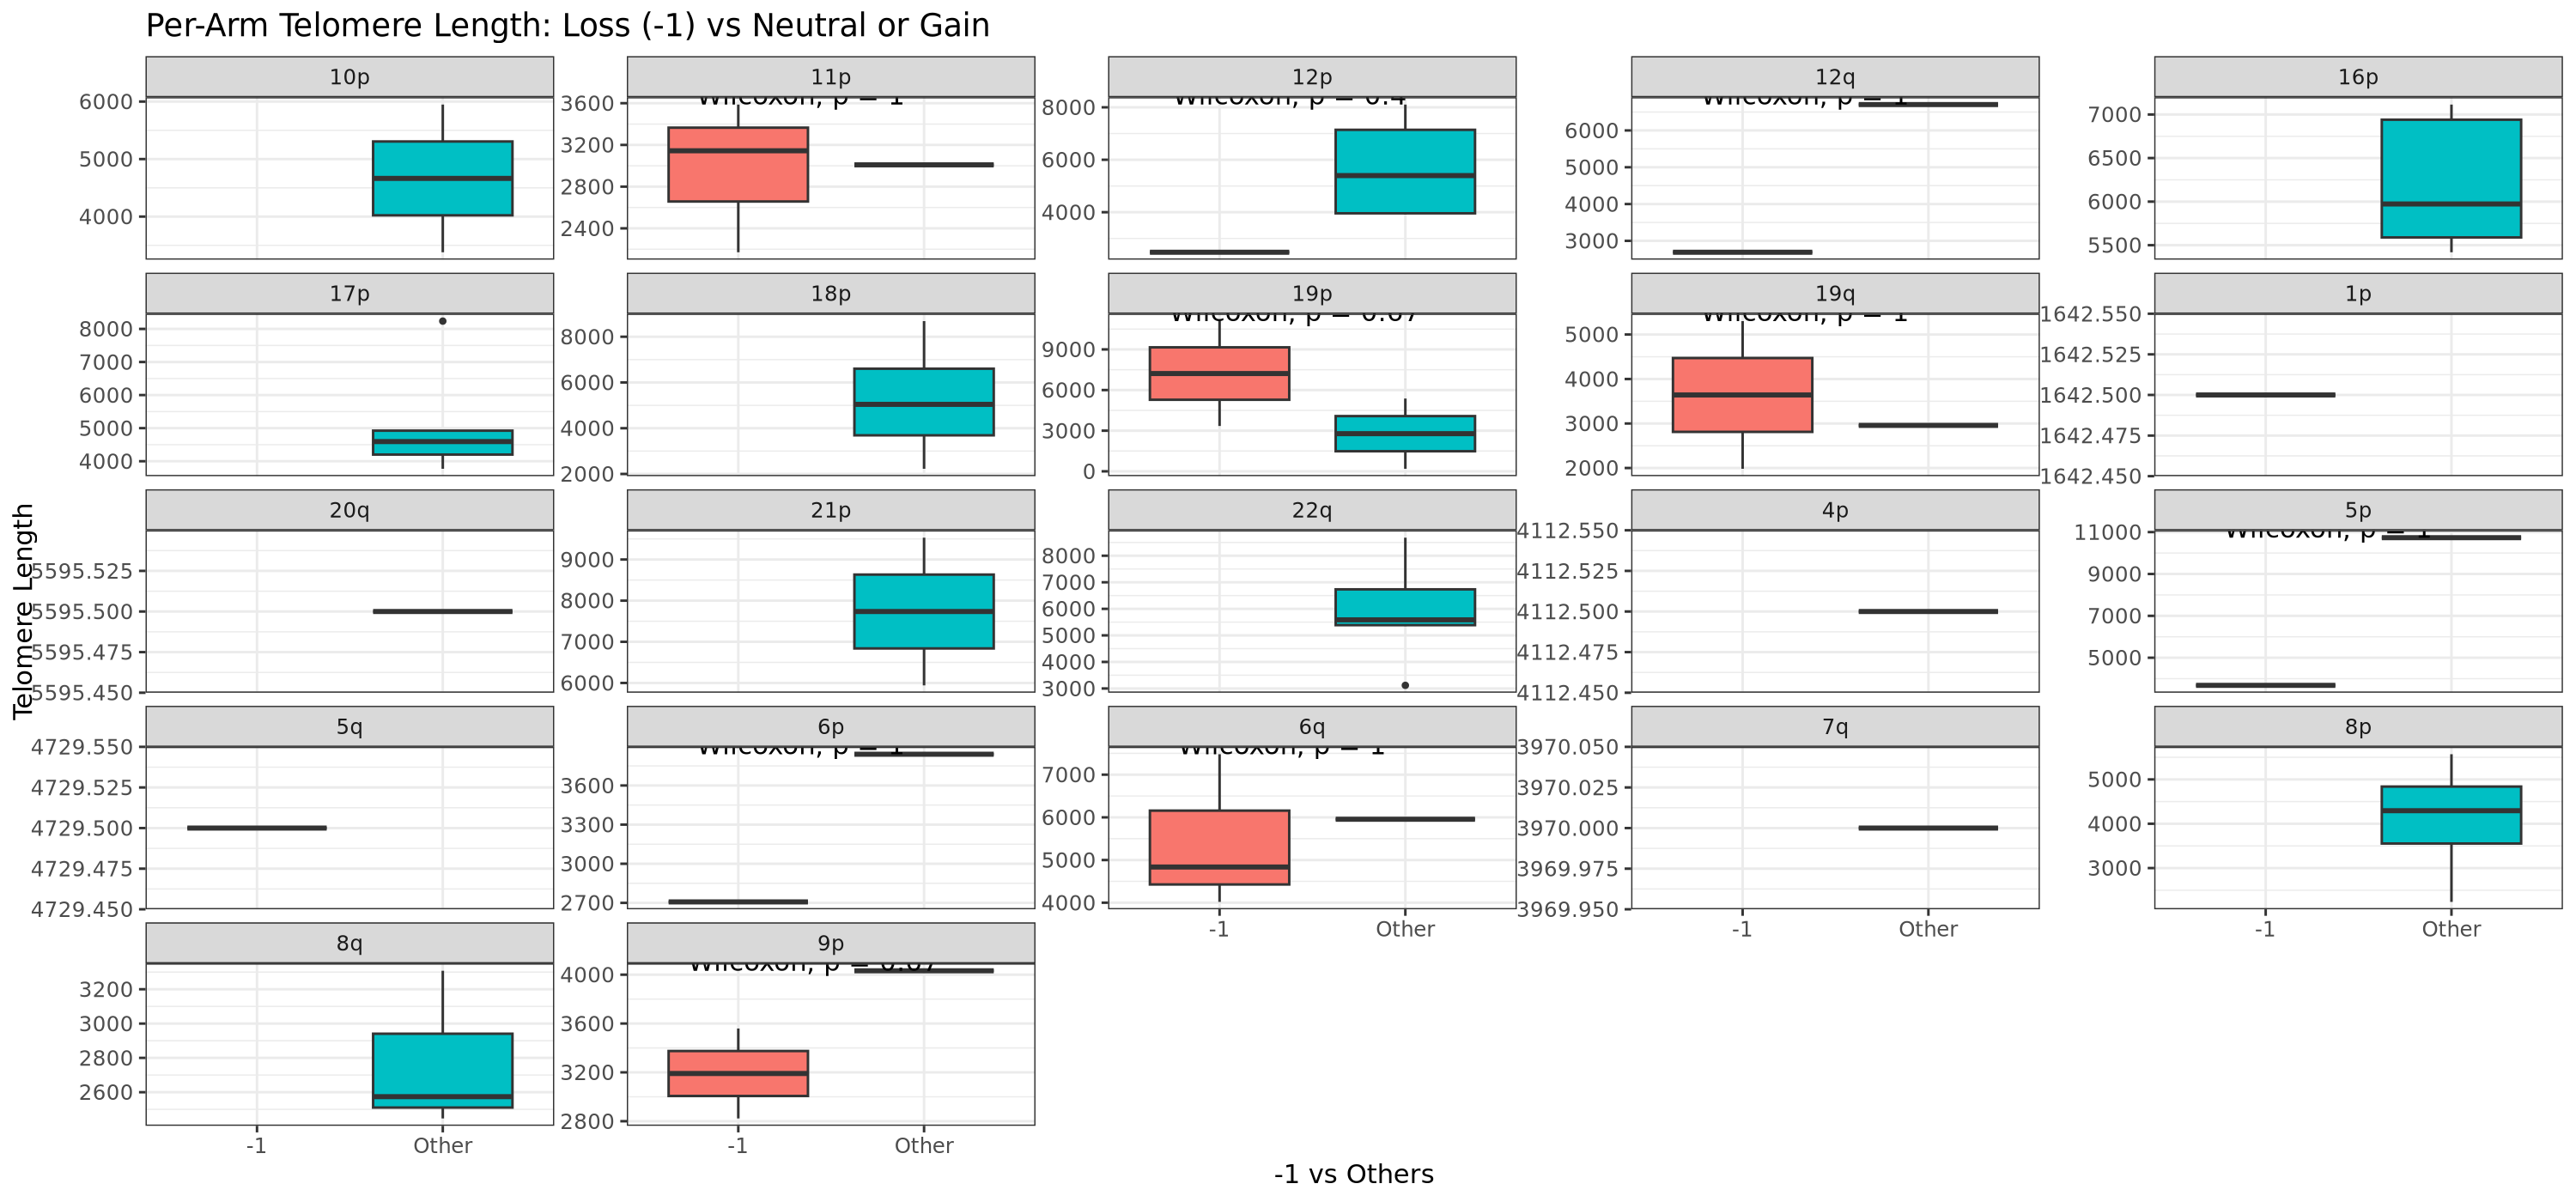

Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”


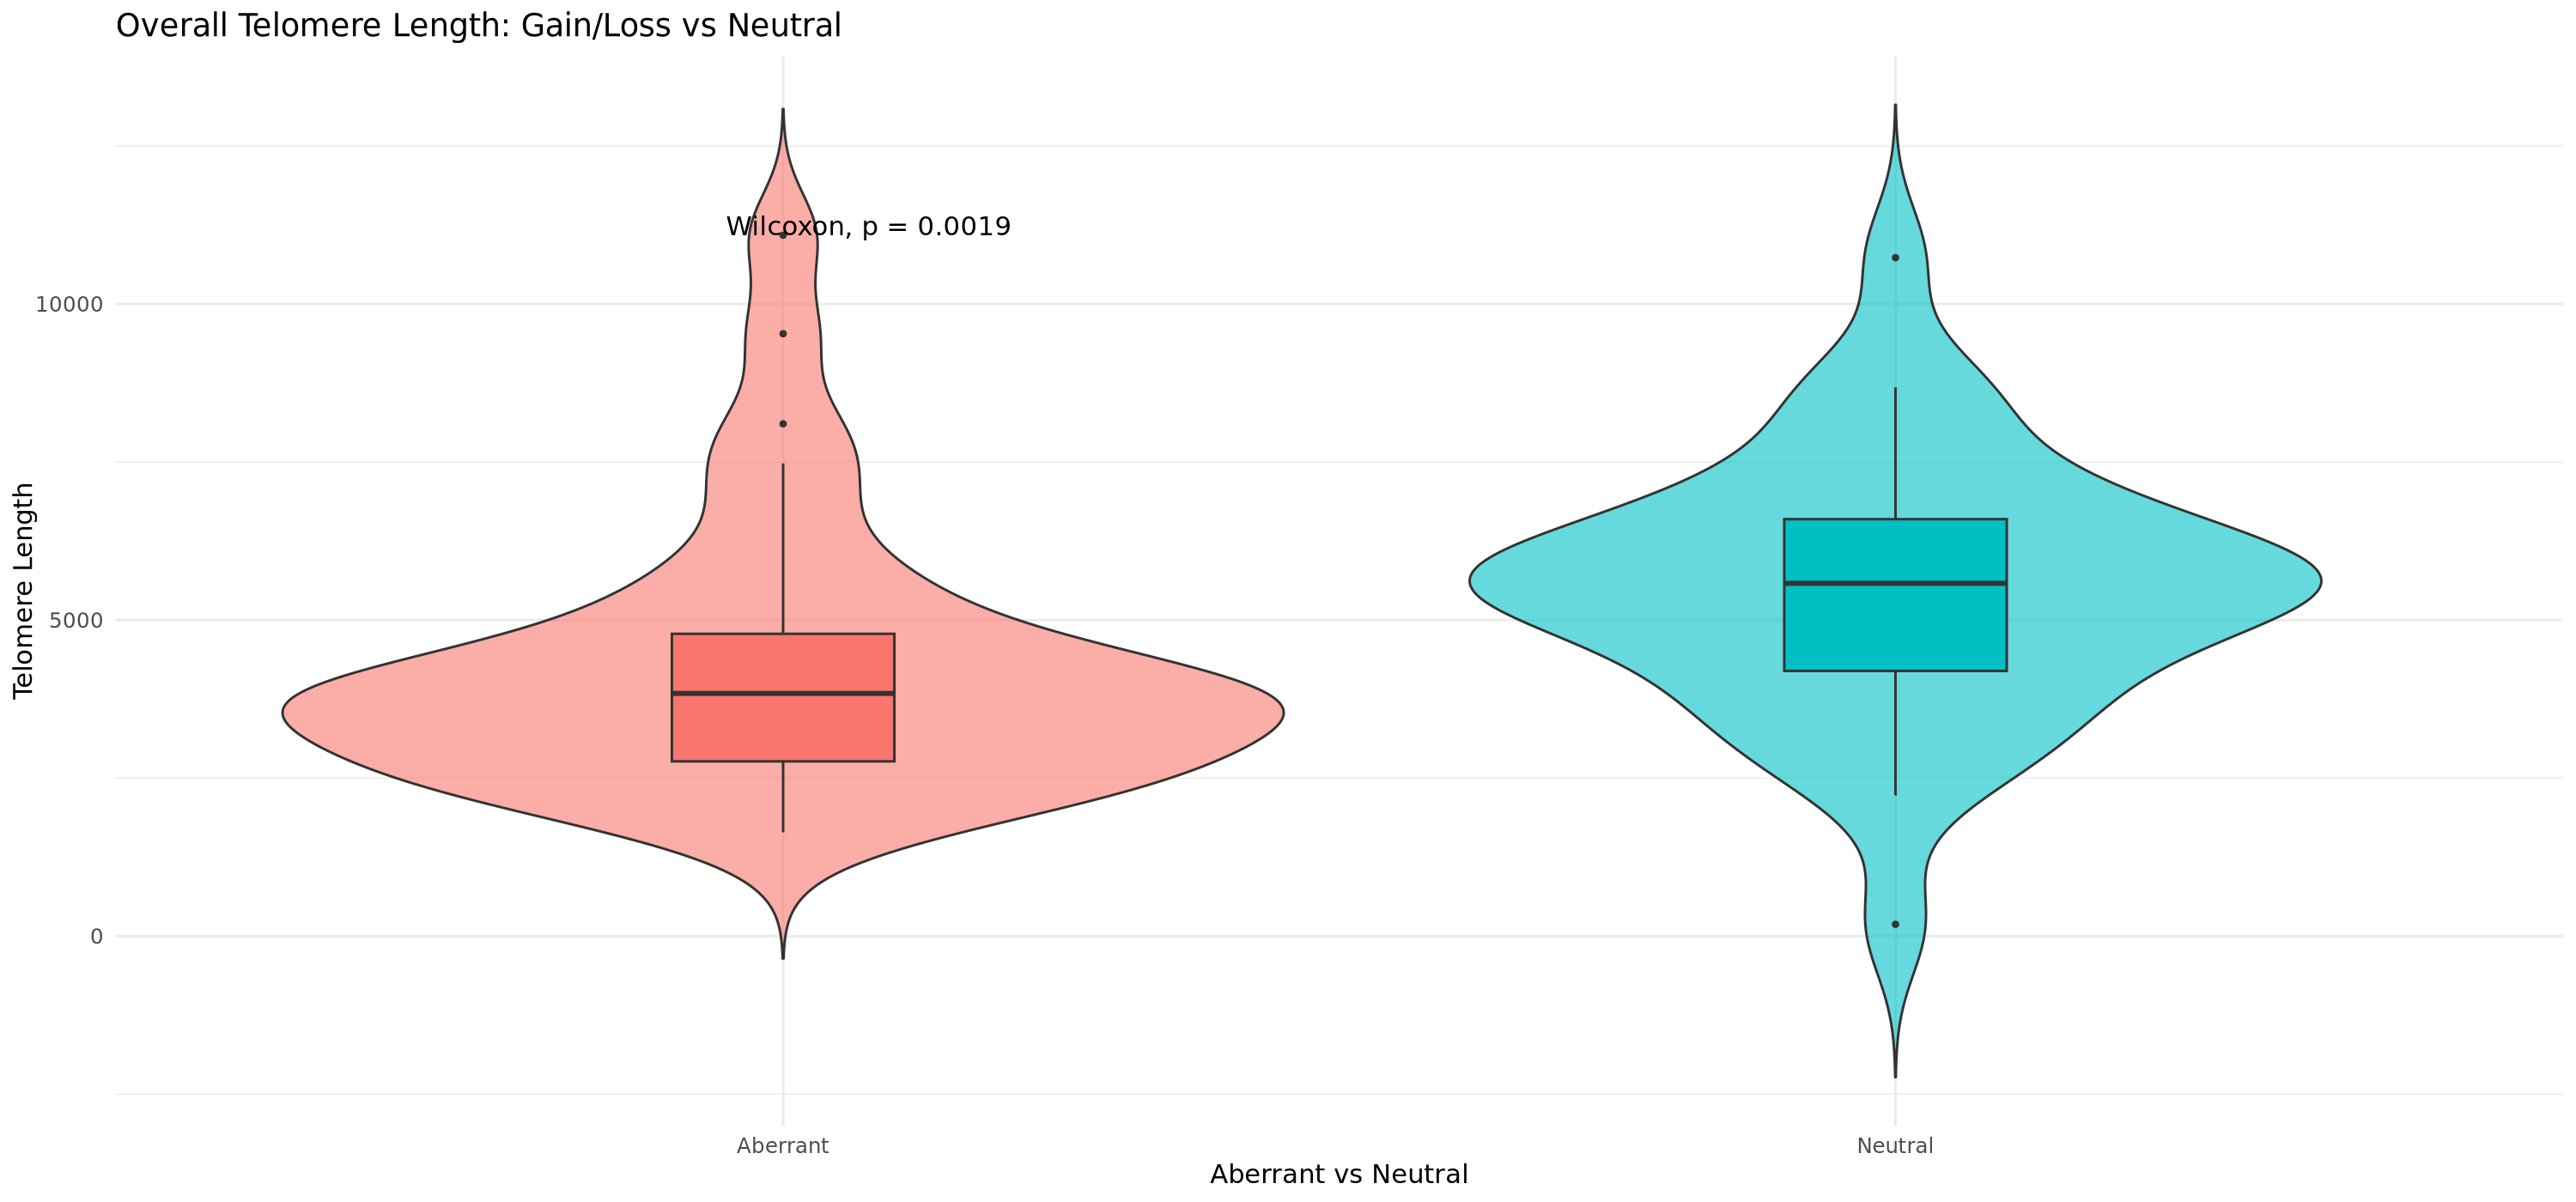

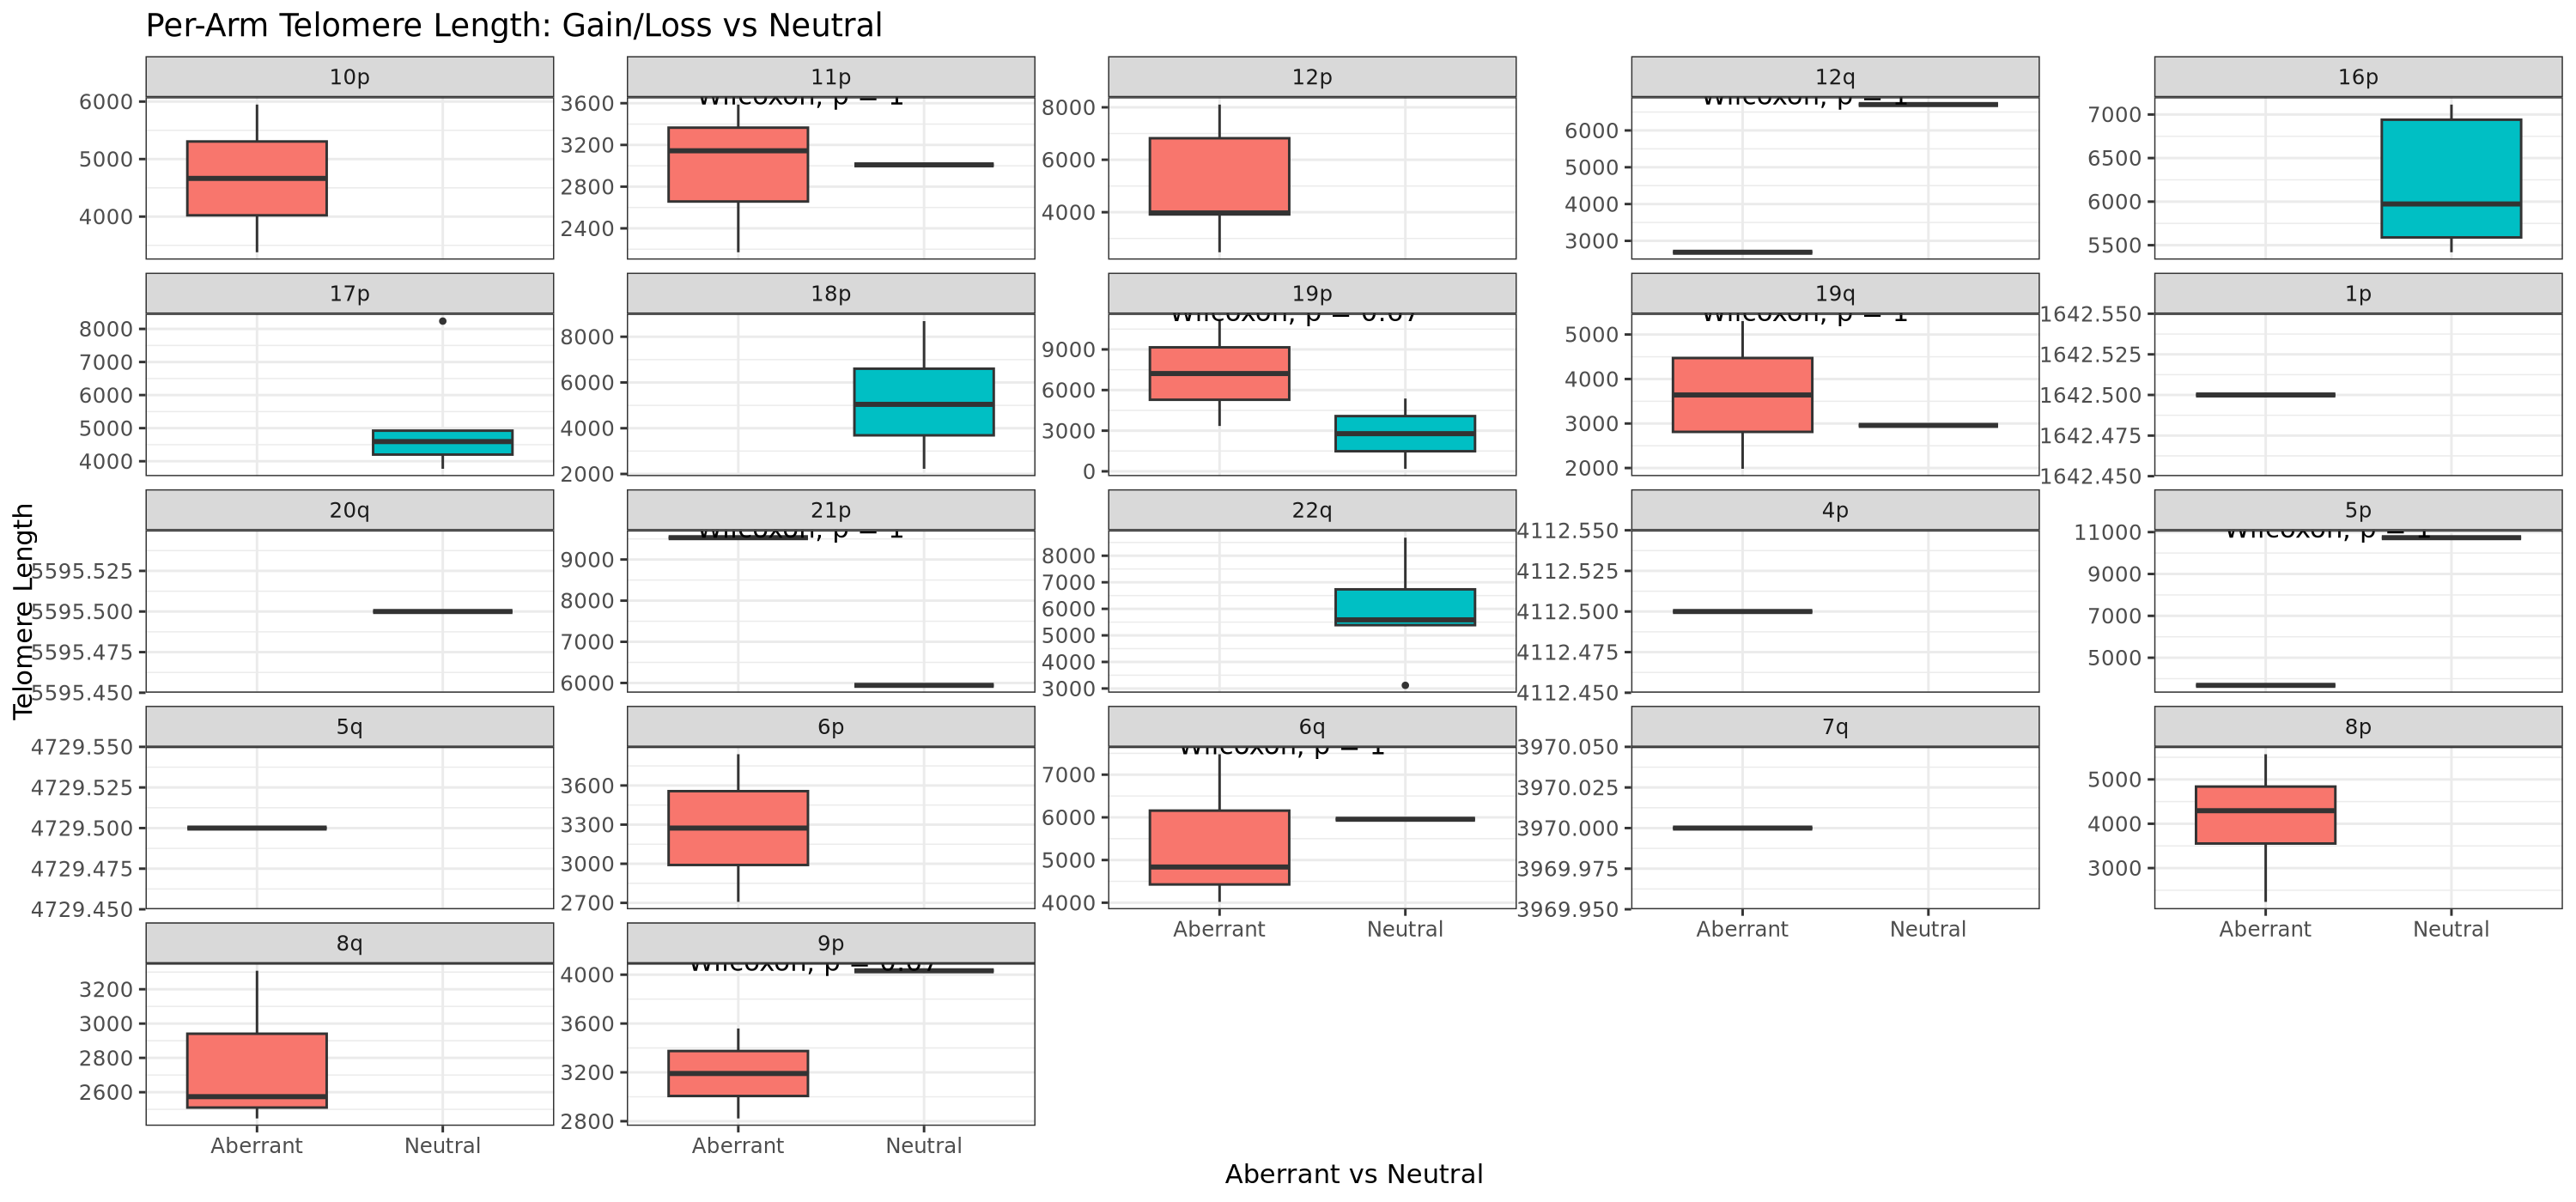

In [32]:
# Load libraries
library(dplyr)
library(ggplot2)
library(ggpubr)
library(stringr)

# Load your data (replace with actual file loading if needed)
# chr_arm_seg_data_data <- read.csv("...")
# tl_data <- read.csv("...")

# ---------------------
# Step 1: Harmonize and merge data
# ---------------------

# Extract chromosome number and arm letter from chr_arm_seg_data_data
chr_arm_seg_data_data <- chr_arm_seg_data_data %>%
  mutate(
    chr_num = str_extract(arm, "\\d+"),
    arm_letter = str_extract(arm, "[pq]"),
    arm_full = paste0(chr_num, arm_letter)
  )

# Extract chromosome number from tl_data and create arm_full
tl_data <- tl_data %>%
  mutate(
    chr_num = str_extract(chr, "\\d+"),
    arm_letter = arm,
    arm_full = paste0(chr_num, arm_letter)
  )

# Merge on sample ID and arm_full
merged_data <- inner_join(
  chr_arm_seg_data_data,
  tl_data,
  by = c("SampleID" = "Sample_prefix", "arm_full" = "arm_full")
)

# ---------------------
# Step 2: Filter clean data and define labels
# ---------------------

plot_data <- merged_data %>%
  filter(arm_call %in% c(-1, 0, 1)) %>%
  mutate(
    arm_call_factor = factor(
      arm_call, levels = c(-1, 0, 1),
      labels = c("Loss (-1)", "Neutral (0)", "Gain (+1)")
    )
  )

# ---------------------
# Step 3: Define comparisons and plot overall
# ---------------------

# Comparison list for 3-group violin/boxplot
my_comparisons <- list(
  c("Loss (-1)", "Neutral (0)"),
  c("Gain (+1)", "Neutral (0)"),
  c("Loss (-1)", "Gain (+1)")
)

# Overall plot with 3-group comparison
p_all <- ggplot(plot_data, aes(x = arm_call_factor, y = final_average_TL_p75, fill = arm_call_factor)) +
  geom_violin(trim = FALSE, alpha = 0.6) +
  geom_boxplot(width = 0.2, outlier.size = 0.8) +
  stat_compare_means(comparisons = my_comparisons, method = "wilcox.test") +
  theme_minimal() +
  labs(
    title = "Overall Telomere Length by Aneuploidy Status",
    x = "Aneuploidy Status",
    y = "Telomere Length"
  ) +
  theme(legend.position = "none")

print(p_all)

# ---------------------
# Step 4: Recode for specific grouped comparisons
# ---------------------

# Function to recode and plot each strategy
plot_grouped_comparison <- function(data, grouping_type, group_labels, group_def, plot_title) {
  df <- data %>%
    mutate(group = case_when(
      arm_call %in% group_def[[1]] ~ group_labels[1],
      arm_call %in% group_def[[2]] ~ group_labels[2],
      TRUE ~ NA_character_
    )) %>%
    filter(!is.na(group))

  # Overall plot
  p_overall <- ggplot(df, aes(x = group, y = final_average_TL_p75, fill = group)) +
    geom_violin(trim = FALSE, alpha = 0.6) +
    geom_boxplot(width = 0.2, outlier.size = 0.8) +
    stat_compare_means(method = "wilcox.test") +
    theme_minimal() +
    labs(
      title = paste("Overall Telomere Length:", plot_title),
      x = grouping_type,
      y = "Telomere Length"
    ) +
    theme(legend.position = "none")
  print(p_overall)

  # Per-arm faceted plot
  p_per_arm <- ggplot(df, aes(x = group, y = final_average_TL_p75, fill = group)) +
    geom_boxplot(outlier.size = 0.8) +
    stat_compare_means(method = "wilcox.test") +
    facet_wrap(~ arm_full, scales = "free_y") +
    theme_bw() +
    labs(
      title = paste("Per-Arm Telomere Length:", plot_title),
      x = grouping_type,
      y = "Telomere Length"
    ) +
    theme(legend.position = "none")

  print(p_per_arm)
}

# ---------------------
# Step 5: Run all 3 grouped comparisons
# ---------------------

# 1. +1 vs (0, -1)
plot_grouped_comparison(
  data = plot_data,
  grouping_type = "+1 vs Others",
  group_labels = c("+1", "Other"),
  group_def = list(c(1), c(0, -1)),
  plot_title = "Gain (+1) vs Neutral or Loss"
)

# 2. -1 vs (0, +1)
plot_grouped_comparison(
  data = plot_data,
  grouping_type = "-1 vs Others",
  group_labels = c("-1", "Other"),
  group_def = list(c(-1), c(0, 1)),
  plot_title = "Loss (-1) vs Neutral or Gain"
)

# 3. (+1, -1) vs 0
plot_grouped_comparison(
  data = plot_data,
  grouping_type = "Aberrant vs Neutral",
  group_labels = c("Aberrant", "Neutral"),
  group_def = list(c(1, -1), c(0)),
  plot_title = "Gain/Loss vs Neutral"
)
